## Load dataset

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg, col
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

In [2]:
spark = SparkSession.builder.appName("FlightProject").getOrCreate()

df = spark.read.parquet("/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned_full.parquet")
df.createOrReplaceTempView("flight_cleaned")

df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 07:12:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/16 07:12:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/16 07:12:24 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/16 07:12:24 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/16 07:12:24 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/03/16 07:12:24 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.


root
 |-- FL_DATE: date (nullable = true)
 |-- AIRLINE_CODE: string (nullable = true)
 |-- DOT_CODE: integer (nullable = true)
 |-- FL_NUMBER: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: double (nullable = true)
 |-- WHEELS_ON: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- DELAY_DUE_CARRIER: integer (nullable = true)
 |-- DELAY_DUE_WEATHER: integer (nullable = true)
 |-- DELAY_DUE_NAS: integer (nullable = true)
 |-- DELAY_DUE_SECURITY: 

26/03/16 07:12:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [3]:
df.show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+-------+-------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|Hour|DayOfWeek|Month|DELAYED|  ROUTE|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+------

In [4]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 1931907
Columns: 30


In [5]:
df.printSchema()

root
 |-- FL_DATE: date (nullable = true)
 |-- AIRLINE_CODE: string (nullable = true)
 |-- DOT_CODE: integer (nullable = true)
 |-- FL_NUMBER: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: double (nullable = true)
 |-- WHEELS_ON: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- DELAY_DUE_CARRIER: integer (nullable = true)
 |-- DELAY_DUE_WEATHER: integer (nullable = true)
 |-- DELAY_DUE_NAS: integer (nullable = true)
 |-- DELAY_DUE_SECURITY: 

In [6]:
df = df.repartition(20)
spark.conf.set("spark.sql.shuffle.partitions", 30)

# Split data into train/test

In [7]:
df=df.drop("AIRPORT_DELAY_RATE","ROUTE_DELAY_RATE","AIRLINE_DELAY_RATE")

In [8]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [9]:
train_df.groupBy("DELAYED").count().show()

+-------+-------+
|DELAYED|  count|
+-------+-------+
|      1| 268773|
|      0|1277014|
+-------+-------+



In [10]:
total = train_df.count()

count_0 = train_df.filter(col("DELAYED") == 0).count()
count_1 = train_df.filter(col("DELAYED") == 1).count()

weight_0 = total / (2 * count_0)
weight_1 = total / (2 * count_1)

print(weight_0, weight_1)

0.6052349465236873 2.8756366896972536


In [11]:
from pyspark.sql.functions import when

train_df = train_df.withColumn(
    "classWeight",
    when(col("DELAYED") == 1, weight_1).otherwise(weight_0)
)

# Preprocessing

In [12]:
airline_delay = train_df.groupBy("AIRLINE_CODE").agg(
    avg("DELAYED").alias("AIRLINE_DELAY_RATE")
)
airport_delay = train_df.groupBy("ORIGIN").agg(
    avg("DELAYED").alias("AIRPORT_DELAY_RATE")
)
route_delay = train_df.groupBy("ROUTE").agg(
    avg("DELAYED").alias("ROUTE_DELAY_RATE")
)

In [13]:
train_df = train_df \
    .join(airport_delay, "ORIGIN", "left") \
    .join(airline_delay, "AIRLINE_CODE", "left") \
    .join(route_delay, "ROUTE", "left")

test_df = test_df \
    .join(airport_delay, "ORIGIN", "left") \
    .join(airline_delay, "AIRLINE_CODE", "left") \
    .join(route_delay, "ROUTE", "left")

In [ ]:
#fill NA, because test set may have new airport/airline/route
global_rate = train_df.select(avg("DELAYED")).first()[0]

train_df = train_df.fillna({
    "AIRLINE_DELAY_RATE": global_rate,
    "AIRPORT_DELAY_RATE": global_rate,
    "ROUTE_DELAY_RATE": global_rate})
test_df = train_df.fillna({
    "AIRLINE_DELAY_RATE": global_rate,
    "AIRPORT_DELAY_RATE": global_rate,
    "ROUTE_DELAY_RATE": global_rate})

In [ ]:
feature_cols = [
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "TAXI_OUT",
    "TAXI_IN",
    "Hour",
    "DayOfWeek",
    "Month",
    "AIRPORT_DELAY_RATE",
    "AIRLINE_DELAY_RATE",
    "ROUTE_DELAY_RATE"]

In [ ]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_df = assembler.transform(train_df)
test_df = assembler.transform(test_df)

In [ ]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

scaler_model = scaler.fit(train_df)

train_df = scaler_model.transform(train_df)
test_df = scaler_model.transform(test_df)

# Logistic Regression

In [ ]:
lr = LogisticRegression(
    labelCol="DELAYED",
    featuresCol="scaled_features",
    weightCol="classWeight", #Help to solve imbalanced 
    maxIter=50)

lr_model = lr.fit(train_df)

26/03/16 07:12:50 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [ ]:
predictions = lr_model.transform(test_df)

predictions.select(
    "DELAYED",
    "prediction",
    "probability").show(10)

+-------+----------+--------------------+
|DELAYED|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.59813725085152...|
|      0|       1.0|[0.45002912185027...|
|      0|       1.0|[0.42488067060023...|
|      0|       0.0|[0.50169237759650...|
|      0|       0.0|[0.50522925444961...|
|      1|       0.0|[0.65580011642154...|
|      1|       0.0|[0.55872354357705...|
|      0|       0.0|[0.64781448191189...|
|      0|       1.0|[0.34360702365569...|
|      0|       0.0|[0.74316389880914...|
+-------+----------+--------------------+
only showing top 10 rows


In [ ]:
evaluator = BinaryClassificationEvaluator(
    labelCol="DELAYED",
    metricName="areaUnderROC")


auc = evaluator.evaluate(predictions)

print("AUC:", auc)

AUC: 0.6663389499993488


In [ ]:
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="DELAYED",
    predictionCol="prediction",
    metricName="accuracy")

accuracy = accuracy_eval.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.6266975980519955


In [ ]:
predictions.groupBy("DELAYED", "prediction").count().show()

+-------+----------+------+
|DELAYED|prediction| count|
+-------+----------+------+
|      0|       1.0|473221|
|      1|       0.0|103825|
|      0|       0.0|803793|
|      1|       1.0|164948|
+-------+----------+------+



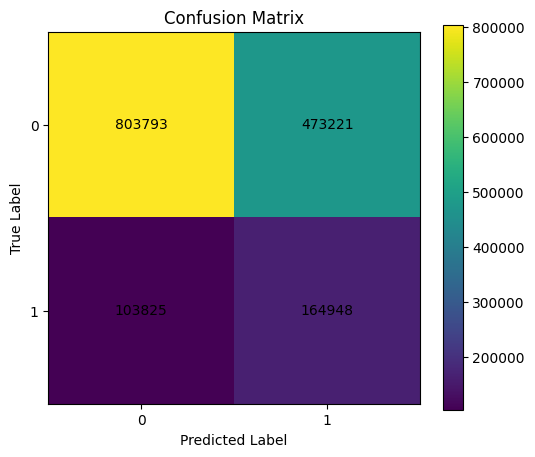

In [ ]:
cm_pd = predictions.select(
    "DELAYED",
    "prediction").toPandas()

# confusion matrix
cm = confusion_matrix(cm_pd["DELAYED"], cm_pd["prediction"])

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1])
plt.yticks([0,1])

# annotate numbers
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.show()

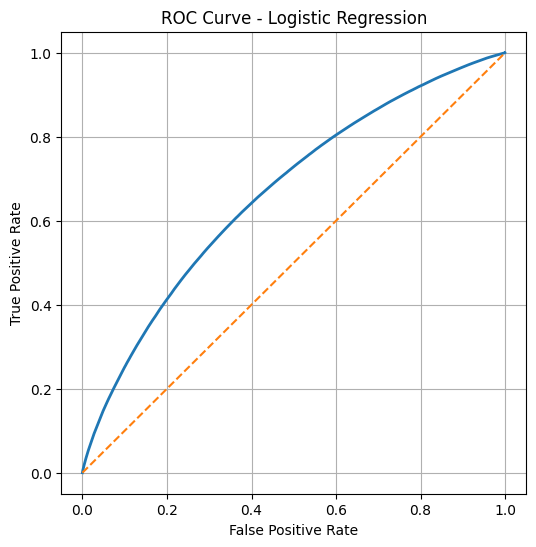

In [ ]:
#train ROC 
trainingSummary = lr_model.summary

roc = trainingSummary.roc.toPandas()

plt.figure(figsize=(6,6))

plt.plot(roc['FPR'], roc['TPR'], linewidth=2)

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.grid()

plt.show()

In [ ]:
#feature importance
coefficients = lr_model.coefficients.toArray()

importance = pd.DataFrame({"feature": feature_cols, "coefficient": coefficients})

importance.sort_values("coefficient", ascending=False)

,feature,coefficient
4,Hour,0.427295
9,ROUTE_DELAY_RATE,0.309379
8,AIRLINE_DELAY_RATE,0.167152
2,TAXI_OUT,0.159369
1,CRS_ELAPSED_TIME,0.057660
6,Month,0.015140
5,DayOfWeek,0.013555
3,TAXI_IN,0.011831
7,AIRPORT_DELAY_RATE,-0.044502
0,DISTANCE,-0.063578


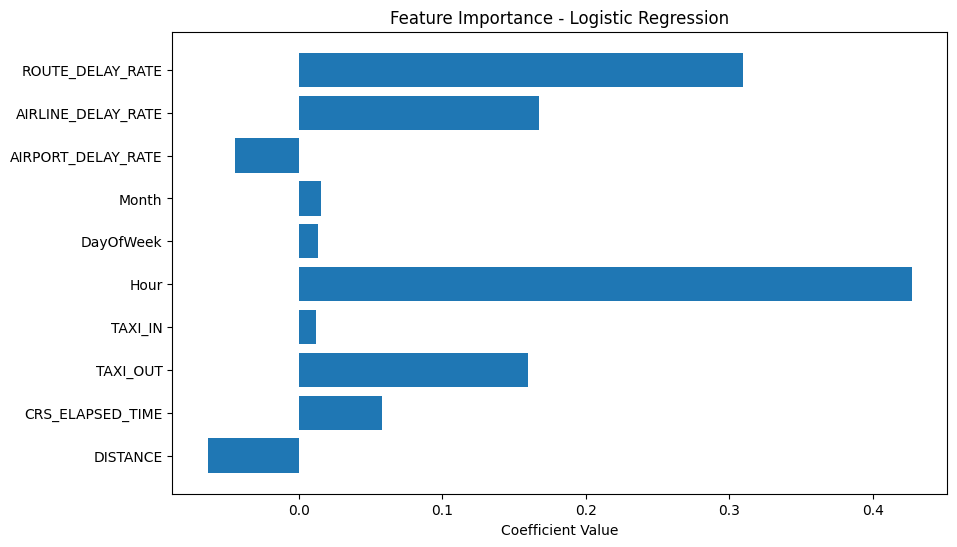

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(importance["feature"], importance["coefficient"])

plt.xlabel("Coefficient Value")
plt.title("Feature Importance - Logistic Regression")
plt.show()